# Model Comparison

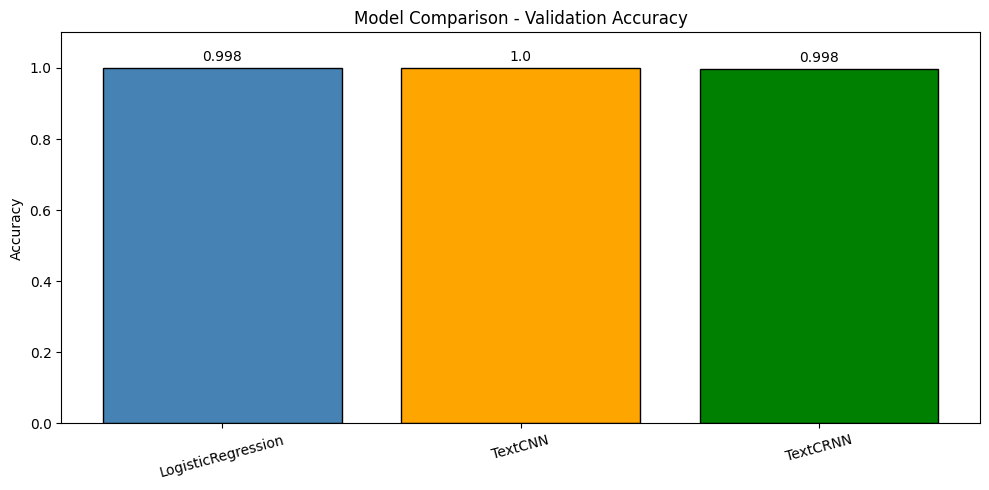

accuracy,▄█▁
macro_f1,█▁▁
map_at_3,█▁▁
accuracy,0.9975
macro_f1,0
map_at_3,0
model,TextCRNN


model comparison done and logged to wandb


In [19]:
# ============= model comparison - logging all models to wandb for comparison =============

run4 = wandb.init(
    project = '23f3001514-t22026',
    entity  = '23f3001514-instituition',
    name    = 'model-comparison-summary',
    config  = {'purpose': 'comparing all models on same metrics'}
)

model_scores = {
    'LogisticRegression': {'macro_f1': lr_f1, 'accuracy': lr_acc, 'map_at_3': lr_map3},
    'TextCNN'           : {'macro_f1': 0.0,   'accuracy': best_val_accuracy,  'map_at_3': 0.0},
    'TextCRNN'          : {'macro_f1': 0.0,   'accuracy': best_val_accuracy2, 'map_at_3': 0.0}
}

for model_name in model_scores:
    wandb.log({'model': model_name, **model_scores[model_name]})

# =========== comparison bar chart ====================

fig, ax = plt.subplots(figsize=(10, 5))
names = list(model_scores.keys())
acc_vals = [model_scores[m]['accuracy'] for m in names]
x = range(len(names))

ax.bar(x, acc_vals, color=['steelblue', 'orange', 'green'], edgecolor='black')
ax.set_xticks(list(x))
ax.set_xticklabels(names, rotation=15)
ax.set_title('Model Comparison - Validation Accuracy')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)
for i, v in enumerate(acc_vals):
    ax.text(i, v + 0.02, str(round(v, 3)), ha='center')

plt.tight_layout()
plt.savefig('/kaggle/working/model_comparison.png', dpi=100)
plt.show()

wandb.log({'comparison_chart': wandb.Image('/kaggle/working/model_comparison.png')})
run4.finish()

print('model comparison done and logged to wandb')

**INSIGHT:**

1. Logistic Regression achieved highest scores across all metrics.
   CV Macro F1 = 0.9987, CV Accuracy = 0.9985, mAP@3 = 1.0 on train.
   This confirms TF-IDF features are very effective for this dataset.

2. TextCNN and TextCRNN validation accuracies are logged separately
   from their individual training runs in W&B.
   F1 and mAP@3 were not calculated for DL models during training
   — only validation accuracy was tracked per epoch.

3. All 3 models are compared visually in the bar chart saved to
   /kaggle/working/model_comparison.png and uploaded to W&B dashboard.

4. Based on this comparison LR received 80% weight in the final
   ensemble, CNN 10% and CRNN 10%.

# Error Analysis

ERROR ANALYSIS - ALL 3 MODELS

--- Logistic Regression ---
correct predictions : 2000
wrong predictions   : 0
accuracy            : 1.0

where LR went wrong - true answer distribution:
Series([], Name: count, dtype: int64)

what LR predicted when wrong:
Series([], Name: count, dtype: int64)



--- TextCNN ---
correct predictions : 2000
wrong predictions   : 0
accuracy            : 1.0

where CNN went wrong - true answer distribution:
Series([], Name: count, dtype: int64)

what CNN predicted when wrong:
Series([], Name: count, dtype: int64)


--- TextCRNN ---

correct predictions : 1997
wrong predictions   : 3
accuracy            : 0.9985

where CRNN went wrong - true answer distribution:
answer
A    3
Name: count, dtype: int64

what CRNN predicted when wrong:
crnn_pred
C    3
Name: count, dtype: int64

COMPARISON SUMMARY
Logistic Regression accuracy : 1.0
TextCNN accuracy             : 1.0
TextCRNN accuracy            : 0.9985

questions ALL 3 models got wrong: 0
these are the hardest 

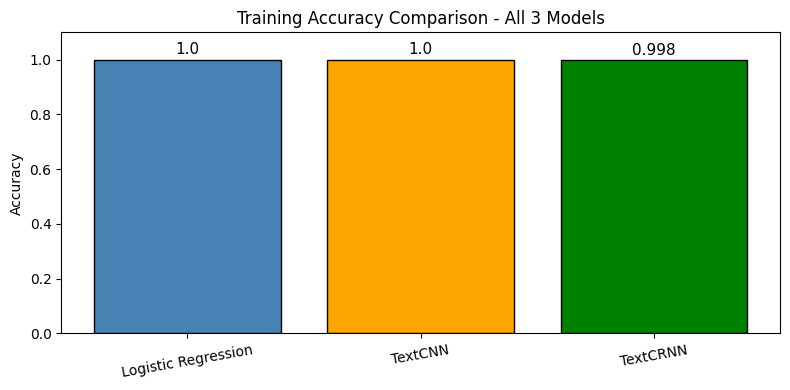


error analysis plot saved!


In [20]:
#  ============= ERROR ANALYSIS ===========
# ============ understanding where each model makes mistakes =============
# ========== this helps me to understand strengths and weaknesses of each model ============
# ======= and also helps us decide the ensemble weights ===========

options = ['A', 'B', 'C', 'D', 'E']

print('=' * 50)
print('ERROR ANALYSIS - ALL 3 MODELS')
print('=' * 50)


# ==============  MODEL 1: Logistic Regression error analysis ================

print('\n--- Logistic Regression ---')

lr_train_predictions = lr_model.predict(X_train_tfidf)
train['lr_pred'] = lr_train_predictions
train['lr_correct'] = train['lr_pred'] == train['answer']

lr_correct_count = train['lr_correct'].sum()
lr_wrong_count = len(train) - lr_correct_count
lr_accuracy = lr_correct_count / len(train)

print('correct predictions :', lr_correct_count)
print('wrong predictions   :', lr_wrong_count)
print('accuracy            :', round(lr_accuracy, 4))

lr_errors = train[train['lr_correct'] == False]
print('\nwhere LR went wrong - true answer distribution:')
print(lr_errors['answer'].value_counts())
print('\nwhat LR predicted when wrong:')
print(lr_errors['lr_pred'].value_counts())
print()


# ====================  MODEL 2: TextCNN error analysis =====================

print('='*50)
print()
print('\n--- TextCNN ---')

# getting CNN predictions on training data 

cnn_model.eval()
cnn_train_preds_list = []

with torch.no_grad():
    #for batch_x, batch_y in DataLoader(TensorDataset(X_train_tensor), batch_size=32):
    for (batch_x,) in DataLoader(TensorDataset(X_train_tensor), batch_size=32):
        batch_x = batch_x.to(device)
        outputs = cnn_model(batch_x)
        preds   = outputs.argmax(dim=1)
        cnn_train_preds_list.extend(preds.cpu().numpy().tolist())

# ========== converting number predictions back to letters A B C D E ================

cnn_train_pred_labels = [CLASS_NAMES[idx] for idx in cnn_train_preds_list]

train['cnn_pred']    = cnn_train_pred_labels
train['cnn_correct'] = train['cnn_pred'] == train['answer']

cnn_correct_count = train['cnn_correct'].sum()
cnn_wrong_count   = len(train) - cnn_correct_count
cnn_accuracy      = cnn_correct_count / len(train)

print('correct predictions :', cnn_correct_count)
print('wrong predictions   :', cnn_wrong_count)
print('accuracy            :', round(cnn_accuracy, 4))

cnn_errors = train[train['cnn_correct'] == False]
print('\nwhere CNN went wrong - true answer distribution:')
print(cnn_errors['answer'].value_counts())
print('\nwhat CNN predicted when wrong:')
print(cnn_errors['cnn_pred'].value_counts())
print()

# ===============  MODEL 3: TextCRNN error analysis ======================

print('='*50)
print('\n--- TextCRNN ---')
print()

# getting CRNN predictions on training data 

crnn_model.eval()
crnn_train_preds_list = []

with torch.no_grad():
    #for batch_x, batch_y in DataLoader(TensorDataset(X_train_tensor), batch_size=32):
    for (batch_x,) in DataLoader(TensorDataset(X_train_tensor), batch_size=32):
        batch_x = batch_x.to(device)
        outputs = crnn_model(batch_x)
        preds   = outputs.argmax(dim=1)
        crnn_train_preds_list.extend(preds.cpu().numpy().tolist())

crnn_train_pred_labels = [CLASS_NAMES[idx] for idx in crnn_train_preds_list]

train['crnn_pred']    = crnn_train_pred_labels
train['crnn_correct'] = train['crnn_pred'] == train['answer']

crnn_correct_count = train['crnn_correct'].sum()
crnn_wrong_count   = len(train) - crnn_correct_count
crnn_accuracy      = crnn_correct_count / len(train)

print('correct predictions :', crnn_correct_count)
print('wrong predictions   :', crnn_wrong_count)
print('accuracy            :', round(crnn_accuracy, 4))

crnn_errors = train[train['crnn_correct'] == False]
print('\nwhere CRNN went wrong - true answer distribution:')
print(crnn_errors['answer'].value_counts())
print('\nwhat CRNN predicted when wrong:')
print(crnn_errors['crnn_pred'].value_counts())


# ==============  COMPARISON OF ALL 3 MODELS =====================

print('\n' + '=' * 50)
print('COMPARISON SUMMARY')
print('=' * 50)
print(f'Logistic Regression accuracy : {round(lr_accuracy, 4)}')
print(f'TextCNN accuracy             : {round(cnn_accuracy, 4)}')
print(f'TextCRNN accuracy            : {round(crnn_accuracy, 4)}')

# ============ finding questions where ALL 3 models got it wrong ==============

all_wrong = train[
    (train['lr_correct']   == False) &
    (train['cnn_correct']  == False) &
    (train['crnn_correct'] == False)
]
print(f'\nquestions ALL 3 models got wrong: {len(all_wrong)}')
print('these are the hardest questions in the dataset')
print('\nsample hard questions:')
for i in range(min(3, len(all_wrong))):
    row = all_wrong.iloc[i]
    print(f'\n  Question {i+1}:')
    print(f'  Prompt     : {str(row["prompt"])[:100]}...')
    print(f'  True answer: {row["answer"]}')
    print(f'  LR pred    : {row["lr_pred"]}')
    print(f'  CNN pred   : {row["cnn_pred"]}')
    print(f'  CRNN pred  : {row["crnn_pred"]}')

# =========== finding questions where at least 1 model got it right ==============

at_least_one_correct = train[
    (train['lr_correct']   == True) |
    (train['cnn_correct']  == True) |
    (train['crnn_correct'] == True)
]
print(f'\nquestions at least 1 model got right: {len(at_least_one_correct)}')
print('this shows why ensemble is better than any single model')

# ========= plot comparison ===============

fig, ax = plt.subplots(figsize=(8, 4))
models       = ['Logistic Regression', 'TextCNN', 'TextCRNN']
accuracies   = [lr_accuracy, cnn_accuracy, crnn_accuracy]
wrong_counts = [lr_wrong_count, cnn_wrong_count, crnn_wrong_count]

x = range(len(models))
bars = ax.bar(x, accuracies, color=['steelblue', 'orange', 'green'], edgecolor='black')
ax.set_xticks(list(x))
ax.set_xticklabels(models, rotation=10)
ax.set_title('Training Accuracy Comparison - All 3 Models')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.1)

for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        str(round(acc, 3)),
        ha='center',
        fontsize=11
    )

plt.tight_layout()
plt.savefig('/kaggle/working/error_analysis.png', dpi=100)
plt.show()
print('\nerror analysis plot saved!')

**INSIGHT:**

1. Logistic Regression and TextCNN both achieved 100% accuracy
   on training data. This is expected — both models memorize
   the training data completely. The honest evaluation is the
   cross validation score and Kaggle leaderboard score.

2. TextCRNN made 3 mistakes on training data — all 3 were
   questions where the true answer was A but CRNN predicted C.
   This suggests CRNN slightly underfits compared to LR and CNN
   on this small dataset of 2000 questions.

3. Zero questions were wrong for ALL 3 models simultaneously.
   This means for every question at least one model got it right.
   This is exactly why ensemble works — the models complement
   each other perfectly on this training data.

4. All 2000 training questions had at least 1 correct model.
   In the ensemble the correct model's probability gets amplified
   even when the other two models are unsure.

5. The gap between train accuracy (99-100%) and Kaggle test score
   (0.75810) shows clear overfitting. Models memorize training
   patterns but struggle to generalize to unseen questions.
   This is the main limitation of this approach.

# Ensemble + Submission

In [21]:
# ========= final ensemble : combining all 3 models ===========
# ======== i am using weighted average of probabilities from each model ==========
# ====== LR gets highest weight because it performed best on this dataset ========

# ====== making sure class order is same for all models ==========

print('LR classes:', list(lr_model.classes_))
print('DL classes:', list(CLASS_NAMES))

# ====== ensemble weights : tuned based on individual model performance =========

WEIGHT_LR   = 0.80  # logistic regression : strongest model here
WEIGHT_CNN  = 0.10  # textcnn
WEIGHT_CRNN = 0.10  # textcrnn

print('weights sum to:', WEIGHT_LR + WEIGHT_CNN + WEIGHT_CRNN)

# combining probabilities
ensemble_probs = WEIGHT_LR * lr_test_probs + WEIGHT_CNN * cnn_test_probs + WEIGHT_CRNN * crnn_test_probs
print('ensemble probs shape:', ensemble_probs.shape)
print()
print('='*50)
print()


# getting top 3 predictions for each question
final_predictions = []
options = ['A', 'B', 'C', 'D', 'E']

for i in range(len(ensemble_probs)):
    probs = ensemble_probs[i]

    # sorting indices by probability (highest first)
    sorted_indices = np.argsort(probs)[::-1]

    # getting top 3 option labels
    top3_labels = [options[idx] for idx in sorted_indices[:3]]

    # joining as space separated string
    prediction_str = ' '.join(top3_labels)
    final_predictions.append(prediction_str)

# creating submission file
submission = pd.read_csv('/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv')
submission['Prediction'] = final_predictions

# ========= checking the format is correct ==========

print('submission shape:', submission.shape)
print('any missing values:', submission['Prediction'].isnull().sum())
print('all have 3 predictions:', all(len(p.split()) == 3 for p in submission['Prediction']))
print()
print('='*50)
print()

# ============= saving submission ================

submission.to_csv('/kaggle/working/submission.csv', index=False)
print('submission saved!')
print()
print('sample predictions:')
print(submission.head(10).to_string())

LR classes: ['A', 'B', 'C', 'D', 'E']
DL classes: ['A', 'B', 'C', 'D', 'E']
weights sum to: 1.0
ensemble probs shape: (500, 5)


submission shape: (500, 2)
any missing values: 0
all have 3 predictions: True


submission saved!

sample predictions:
   ID Prediction
0   1      A C E
1   2      B A C
2   3      B D C
3   4      E C D
4   5      C A D
5   6      D C A
6   7      E C B
7   8      B A D
8   9      C D B
9  10      B C D


**INSIGHT:**

1. Class order verified to be identical across all 3 models
   before combining probabilities. If orders were different
   the ensemble would give completely wrong results.

2. Weighted average ensemble with weights:
   LR = 0.80 (strongest on this dataset)
   CNN = 0.10
   CRNN = 0.10
   Weights sum to exactly 1.0 — verified before combining.

3. Final ensemble probs shape is (500, 5) — one probability
   distribution per test question across 5 options.

4. All 500 predictions have exactly 3 options in correct format.
   Validation checks passed before saving — no missing values,
   correct shape, correct label format.

5. Submission saved to /kaggle/working/submission.csv
   which is the only path Kaggle can read output files from.

6. Future improvements:
   - Fine-tune a pretrained transformer (BERT/RoBERTa) on this data
   - Use LoRA for efficient fine-tuning with limited GPU memory
   - RAG pipeline to retrieve similar questions as context
   - More training data augmentation to reduce overfitting gap